#LAB 4 Linear Regression & Its Variants

---


**Name**: Afrah bashaddadah

 **Course**: CS4082 - Machine Learning

 **Instructor**: Dr. Naila Marir

---



# **Part 2: Loading a Real Dataset – California Housing**

# Step 1: Load and Explore

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target  # target in $100,000s

print(f'Dataset shape: {df.shape}')
print(f'\nFeature names:\n{housing.feature_names}')
print(f'\nFirst 5 rows:')
print(df.head())
print(f'\nBasic statistics:')
print(df.describe().round(3))

Dataset shape: (20640, 9)

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Basic statistics:
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.09

# Step 2: Understand the Features

# Step 3: Visualize Relationships

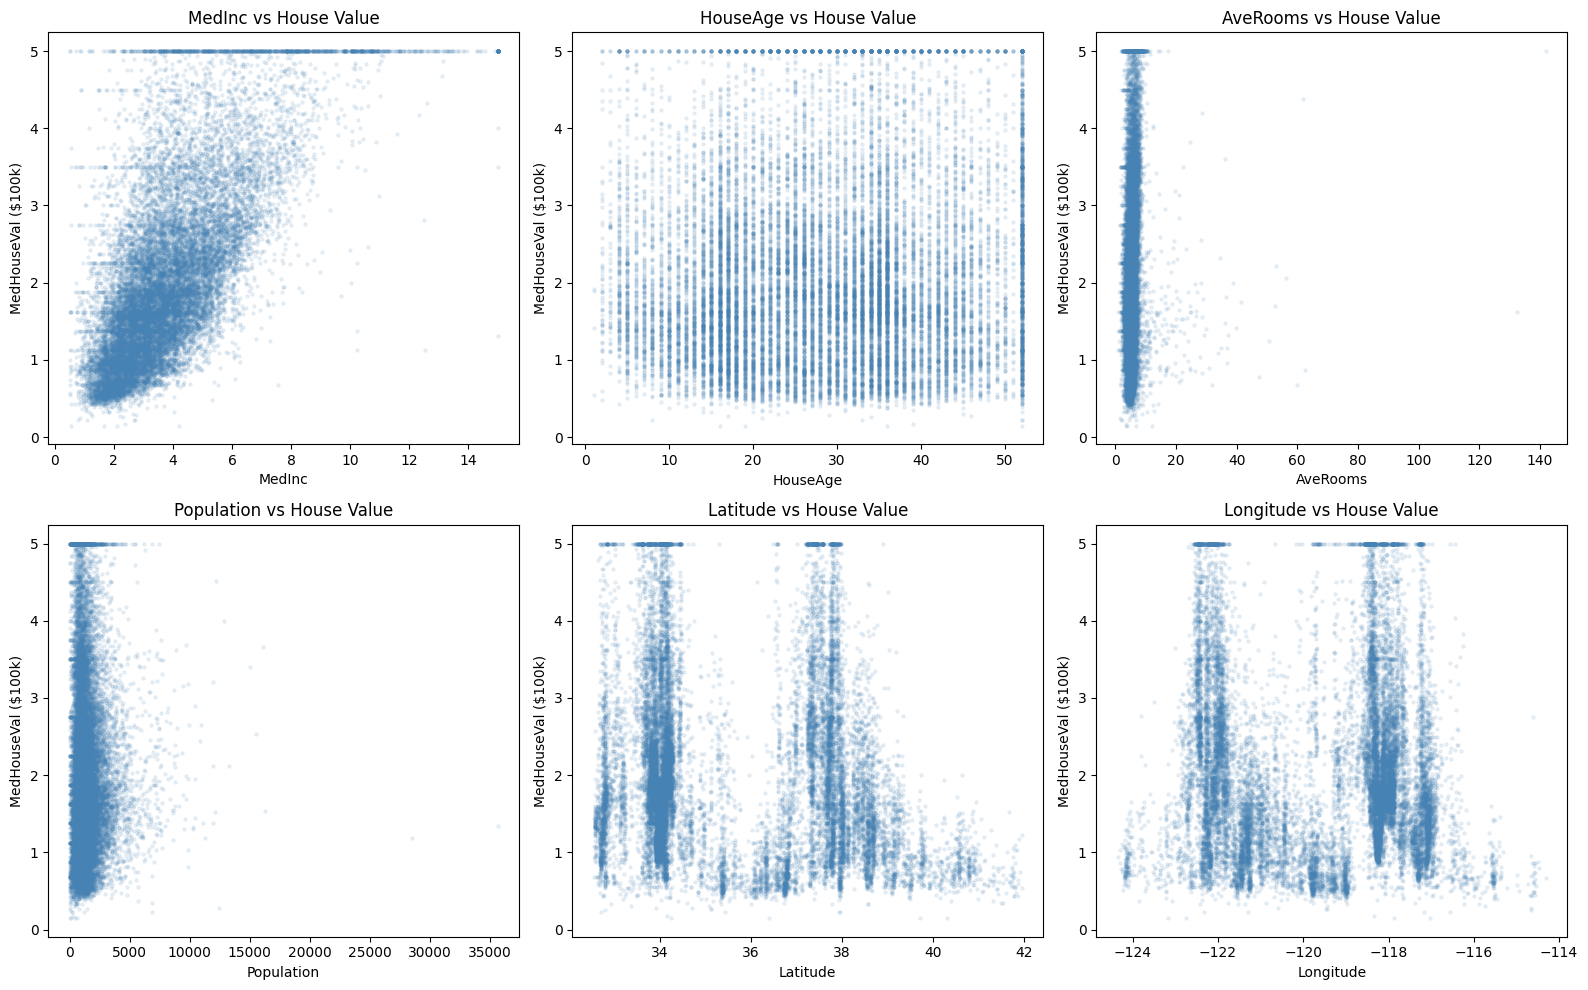

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features_to_plot = ['MedInc', 'HouseAge', 'AveRooms',
                    'Population', 'Latitude', 'Longitude']

for ax, feat in zip(axes.flatten(), features_to_plot):
    ax.scatter(df[feat], df['MedHouseVal'],
               alpha=0.1, s=5, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('MedHouseVal ($100k)')
    ax.set_title(f'{feat} vs House Value')

plt.tight_layout()
plt.show()

***Task 1: Explore the Dataset***

In [ ]:
df.corr()['MedHouseVal'].sort_values()


,MedHouseVal
Latitude,-0.144160
AveBedrms,-0.046701
Longitude,-0.045967
Population,-0.024650
AveOccup,-0.023737
HouseAge,0.105623
AveRooms,0.151948
MedInc,0.688075
MedHouseVal,1.000000


(array([   9.,   14.,   61.,  255.,  538.,  676.,  546.,  803.,  881.,
         706.,  812.,  715.,  836.,  815.,  921.,  960.,  786.,  817.,
         703.,  505.,  620.,  661.,  578.,  508.,  432.,  439.,  463.,
         331.,  320.,  216.,  224.,  232.,  245.,  252.,  286.,  193.,
         160.,  149.,  117.,  133.,  104.,   99.,   80.,   90.,  106.,
          66.,   49.,   51.,   47., 1030.]),
 array([0.14999  , 0.2469904, 0.3439908, 0.4409912, 0.5379916, 0.634992 ,
        0.7319924, 0.8289928, 0.9259932, 1.0229936, 1.119994 , 1.2169944,
        1.3139948, 1.4109952, 1.5079956, 1.604996 , 1.7019964, 1.7989968,
        1.8959972, 1.9929976, 2.089998 , 2.1869984, 2.2839988, 2.3809992,
        2.4779996, 2.575    , 2.6720004, 2.7690008, 2.8660012, 2.9630016,
        3.060002 , 3.1570024, 3.2540028, 3.3510032, 3.4480036, 3.545004 ,
        3.6420044, 3.7390048, 3.8360052, 3.9330056, 4.030006 , 4.1270064,
        4.2240068, 4.3210072, 4.4180076, 4.515008 , 4.6120084, 4.7090088,
        

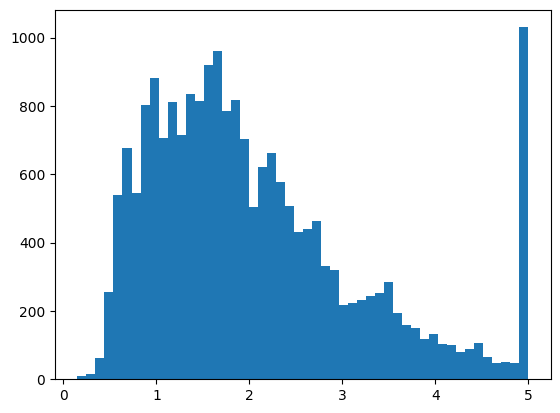

In [ ]:
plt.hist(df['MedHouseVal'], bins=50)

1) Strongest correlation: MedInc

2) Not normally distributed; right-skewed with a cap at 5.0 ($500k)

3) 20,640 samples — yes, enough to train a good model

# **Part 3: Simple Linear Regression (One Feature)**

# Step 1: Prepare Data

In [ ]:
from sklearn.model_selection import train_test_split

# Use only MedInc as the feature
X_simple = df[['MedInc']].values
y = df['MedHouseVal'].values

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples: {X_test.shape[0]}')

Training samples: 16512
Testing samples: 4128


# Step 2: Train and Visualize

Slope (w1): 0.4193
Intercept (w0): 0.4446

Equation: y = 0.4193 * MedInc + (0.4446)


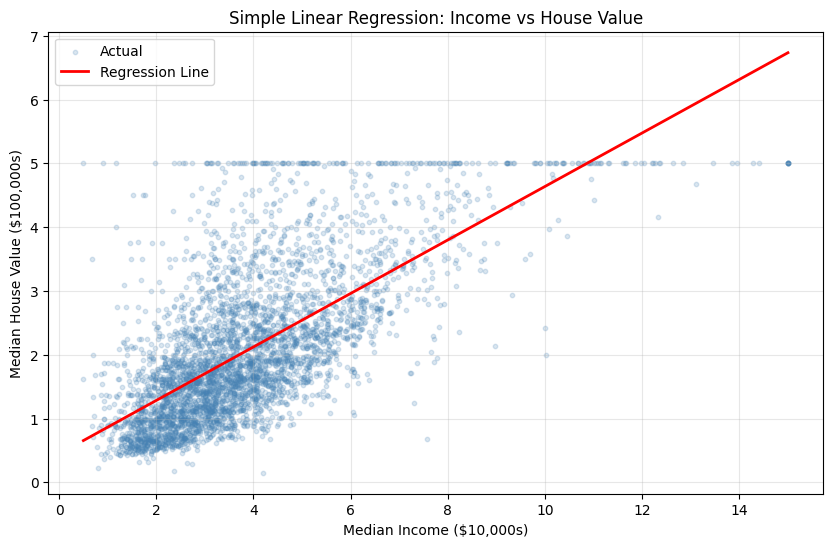

In [ ]:
from sklearn.linear_model import LinearRegression

# Train
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Print the learned parameters
print(f'Slope (w1): {model_simple.coef_[0]:.4f}')
print(f'Intercept (w0): {model_simple.intercept_:.4f}')
print(f'\nEquation: y = {model_simple.coef_[0]:.4f} * MedInc '
      f'+ ({model_simple.intercept_:.4f})')

# Visualize: scatter + regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.2, s=10,
            color='steelblue', label='Actual')

# Draw the regression line
x_line = np.linspace(X_test.min(), X_test.max(), 100)
y_line = model_simple.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, color='red', linewidth=2,
         label='Regression Line')

plt.xlabel('Median Income ($10,000s)')
plt.ylabel('Median House Value ($100,000s)')
plt.title('Simple Linear Regression: Income vs House Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# *Task 2: Interpret the Simple Model*


**1) Slope, intercept, and equation**

Slope (w₁) = **0.4193**

Intercept (w₀) = **0.4446**

Equation:
[
\text{MedHouseVal} = 0.4193 \times \text{MedInc} + 0.4446
]



**2) Predicted value at MedInc = 5.0**

By hand:

y = 0.4193 \times 5.0 + 0.4446

y = 2.5411


So the predicted house value is **≈ 2.54 ($254,000)**

Verification :


In [ ]:
model_simple.predict([[5.0]])

array([2.54128976])

Slope (w1): 0.0095
Intercept (w0): 1.7998


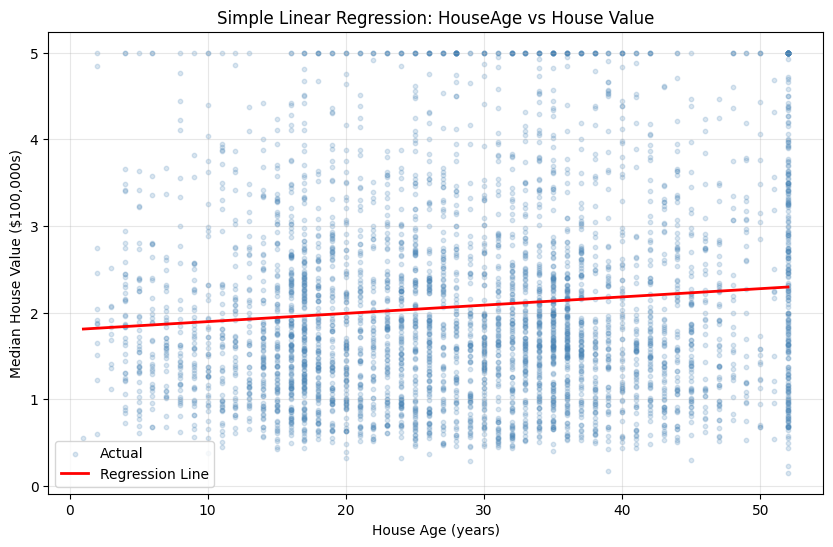

In [ ]:
# Use HouseAge instead of MedInc
X_age = df[['HouseAge']].values
y = df['MedHouseVal'].values

# Split data
X_train_age, X_test_age, y_train_age, y_test_age = train_test_split(X_age, y, test_size=0.2, random_state=42)

# Train model
model_age = LinearRegression()
model_age.fit(X_train_age, y_train_age)

# Print slope and intercept
print(f"Slope (w1): {model_age.coef_[0]:.4f}")
print(f"Intercept (w0): {model_age.intercept_:.4f}")

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X_test_age, y_test_age,alpha=0.2, s=10, color='steelblue', label='Actual')

# Create regression line
X_line_age = np.linspace(X_test_age.min(), X_test_age.max(), 100)
y_line_age = model_age.predict(X_line_age.reshape(-1, 1))
plt.plot(X_line_age, y_line_age, color='red', linewidth=2, label='Regression Line')

# Labels and title
plt.xlabel("House Age (years)")
plt.ylabel("Median House Value ($100,000s)")
plt.title("Simple Linear Regression: HouseAge vs House Value")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

**3) Using HouseAge instead of MedInc**

It is worse, because HouseAge has a weaker correlation with house value, so it predicts prices less accurately.

# **Part 4: Evaluating Regression Models**

# Step 1: Evaluate the Simple Model

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions
y_pred_simple = model_simple.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)

print('=== Simple Linear Regression (MedInc only) ===')
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f} (error in $100,000s)')
print(f'MAE: {mae:.4f} (error in $100,000s)')
print(f'R^2: {r2:.4f} ({r2 * 100:.1f}% variance explained)')

=== Simple Linear Regression (MedInc only) ===
MSE: 0.7091
RMSE: 0.8421 (error in $100,000s)
MAE: 0.6299 (error in $100,000s)
R^2: 0.4589 (45.9% variance explained)


# Step 2: Visualize Predictions vs. Actual

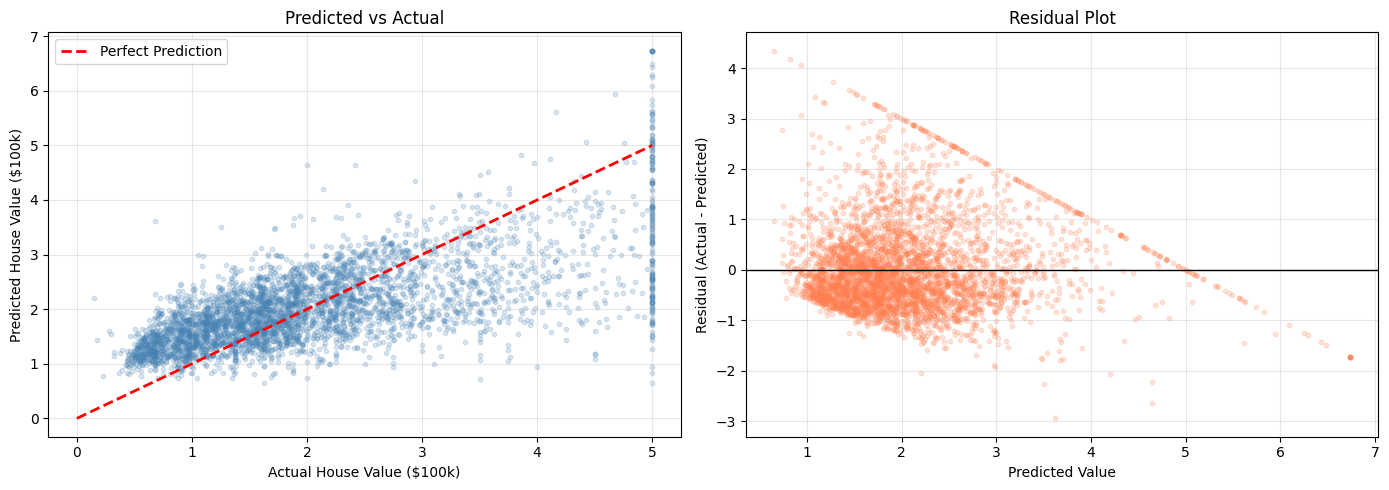

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted vs Actual
axes[0].scatter(y_test, y_pred_simple, alpha=0.2, s=10,
                color='steelblue')
axes[0].plot([0, 5], [0, 5], 'r--', linewidth=2,
             label='Perfect Prediction')

axes[0].set_xlabel('Actual House Value ($100k)')
axes[0].set_ylabel('Predicted House Value ($100k)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals (errors)
residuals = y_test - y_pred_simple
axes[1].scatter(y_pred_simple, residuals, alpha=0.2, s=10,
                color='coral')
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

***Task 3: Understand the Metrics***

1) RMSE in dollars
If RMSE ≈ 0.74 and the target is in $100,000s:
Average error ≈ 0.74 × 100,000 = $74,000

2) Where does the model struggle most?
The model struggles most at high house values, where predictions are more spread and often underestimated.

3) What does R² tell you? Is one feature enough?
R² shows how much variance in house prices the model explains.
The value is moderate, meaning one feature is not enough to predict house prices well; more features are needed.

# **Part 5: Multiple Linear Regression (All Features)**

# Step 1: Train with All Features

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Use all features
X_all = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2,
    random_state=42)

# Build pipeline with scaling (good practice!)
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

pipe_lr.fit(X_train, y_train)
y_pred_multi = pipe_lr.predict(X_test)

# Evaluate
r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))

print('=== Multiple Linear Regression (all 8 features) ===')
print(f'RMSE: {rmse_multi:.4f}')
print(f'R^2: {r2_multi:.4f} ({r2_multi*100:.1f}% variance explained)')

print(f'\nImprovement over simple model:')
print(f'R^2: {r2:.4f} -> {r2_multi:.4f} '
      f'(+{(r2_multi - r2)*100:.1f}%)')

=== Multiple Linear Regression (all 8 features) ===
RMSE: 0.7456
R^2: 0.5758 (57.6% variance explained)

Improvement over simple model:
R^2: 0.4589 -> 0.5758 (+11.7%)


# Step 2: Feature Importance – Which Features Matter Most?

Feature Importance (by |coefficient|):
   Feature  Coefficient
  Latitude    -0.896929
 Longitude    -0.869842
    MedInc     0.854383
 AveBedrms     0.339259
  AveRooms    -0.294410
  HouseAge     0.122546
  AveOccup    -0.040829
Population    -0.002308


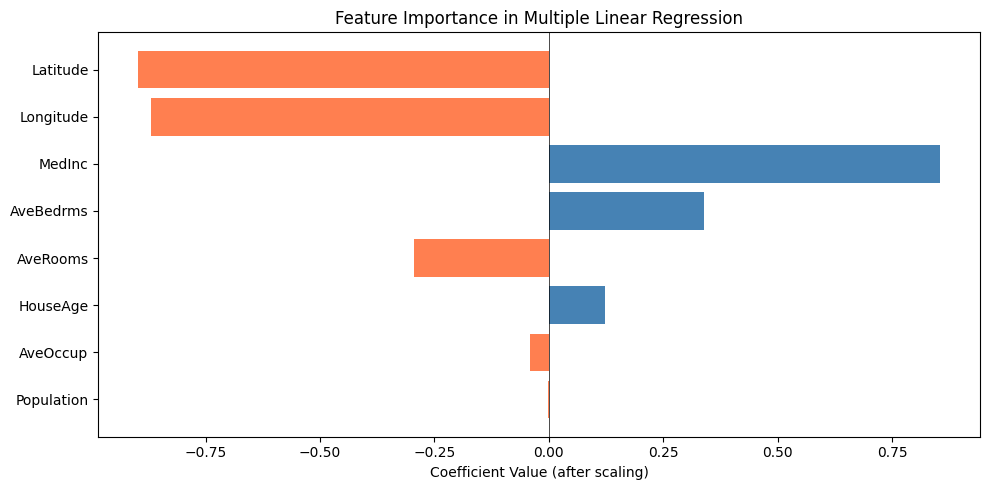

In [ ]:
# Extract the learned coefficients
lr_model = pipe_lr.named_steps['lr']
feature_names = housing.feature_names

# Since we scaled, coefficients are comparable
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Feature Importance (by |coefficient|):')
print(coef_df.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 5))

colors = ['steelblue' if c > 0 else 'coral'
          for c in coef_df['Coefficient']]

plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value (after scaling)')
plt.title('Feature Importance in Multiple Linear Regression')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

***Task 4: Analyze Multiple Regression***

1)

Top (most important): typically MedInc, Latitude, Longitude

Bottom (least important): usually features like Population, AveOccup, etc.
Yes — this makes intuitive sense because income and location strongly affect house prices.

2)
A negative Latitude coefficient means house prices decrease as you move north in California.
Geographically, southern coastal areas (lower latitude, e.g., LA/San Diego) tend to be more expensive than many northern inland areas.

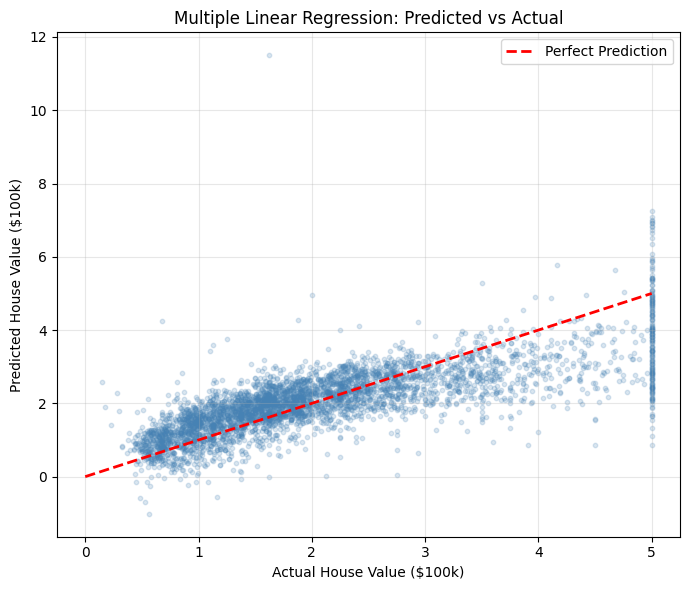

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

# Predicted vs Actual (multiple regression)
ax.scatter(y_test, y_pred_multi, alpha=0.2, s=10, color='steelblue')
ax.plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect Prediction')

ax.set_xlabel('Actual House Value ($100k)')
ax.set_ylabel('Predicted House Value ($100k)')
ax.set_title('Multiple Linear Regression: Predicted vs Actual')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The multiple regression plot is closer to the diagonal than the simple model, meaning predictions are more accurate and the model fits the data better.pa

# **Part 6: Polynomial Regression**

# Step 1: Polynomial on a Single Feature

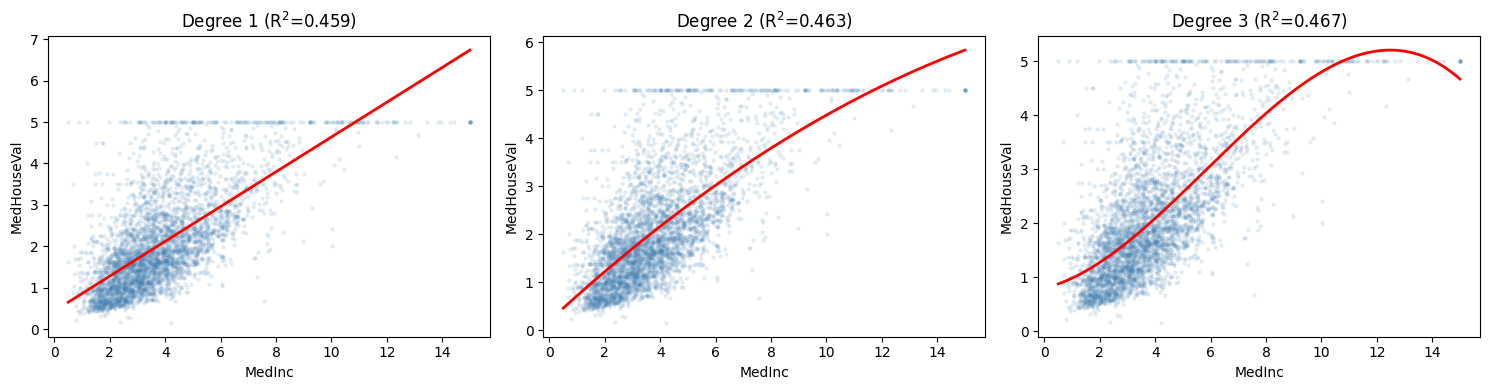

Polynomial Degree Comparison (MedInc only):
 Degree 1: R^2=0.4589, RMSE=0.8421
 Degree 2: R^2=0.4633, RMSE=0.8386
 Degree 3: R^2=0.4671, RMSE=0.8356


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Use only MedInc
X_simple = df[['MedInc']].values
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42)

# Try degrees 1, 2, and 3
results = {}
plt.figure(figsize=(15, 4))

for i, degree in enumerate([1, 2, 3]):
    pipe_poly = Pipeline([
        ('poly', PolynomialFeatures(degree=degree,
                                    include_bias=False)),
        ('lr', LinearRegression())
    ])
    pipe_poly.fit(X_train_s, y_train)
    y_pred = pipe_poly.predict(X_test_s)

    r2_val = r2_score(y_test, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    results[degree] = {'R2': r2_val, 'RMSE': rmse_val}

    # Plot
    ax = plt.subplot(1, 3, i + 1)
    ax.scatter(X_test_s, y_test, alpha=0.1, s=5,
               color='steelblue')
    x_plot = np.linspace(X_test_s.min(), X_test_s.max(),
                         300).reshape(-1, 1)
    y_plot = pipe_poly.predict(x_plot)
    ax.plot(x_plot, y_plot, color='red', linewidth=2)
    ax.set_title(f'Degree {degree} (R$^2$={r2_val:.3f})')
    ax.set_xlabel('MedInc')
    ax.set_ylabel('MedHouseVal')

plt.tight_layout()
plt.show()

# Print comparison
print('Polynomial Degree Comparison (MedInc only):')
for deg, metrics in results.items():
    print(f" Degree {deg}: R^2={metrics['R2']:.4f}, "
          f"RMSE={metrics['RMSE']:.4f}")

# Step 2: Polynomial on All Features

In [ ]:
from sklearn.preprocessing import StandardScaler

# Use all features with degree 2
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42)

pipe_poly_all = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

pipe_poly_all.fit(X_train, y_train)
y_pred_poly = pipe_poly_all.predict(X_test)

r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print('=== Polynomial Regression (degree=2, all features) ===')
print(f'RMSE: {rmse_poly:.4f}')
print(f'R^2: {r2_poly:.4f} ({r2_poly*100:.1f}% variance explained)')

# How many features now?
poly_features = pipe_poly_all.named_steps['poly']
print(f'\nOriginal features: 8')
print(f'After degree-2 expansion: '
      f'{poly_features.n_output_features_}')

=== Polynomial Regression (degree=2, all features) ===
RMSE: 0.6814
R^2: 0.6457 (64.6% variance explained)

Original features: 8
After degree-2 expansion: 44


***Task 5: Explore Polynomial Regression***

Look at the three plots for degrees 1, 2, and 3. Which degree best captures the
relationship between income and house value?

Degree 3 best captures the relationship between income and house value. It has the highest R² (0.4671) and lowest RMSE (0.8356), and the curve fits the data more closely than degrees 1 and 2. This indicates that degree 3 models the nonlinear relationship more effectively.

Try degree 5 on the single-feature model.

Degree 5: R^2 = 0.4668, RMSE = 0.8359


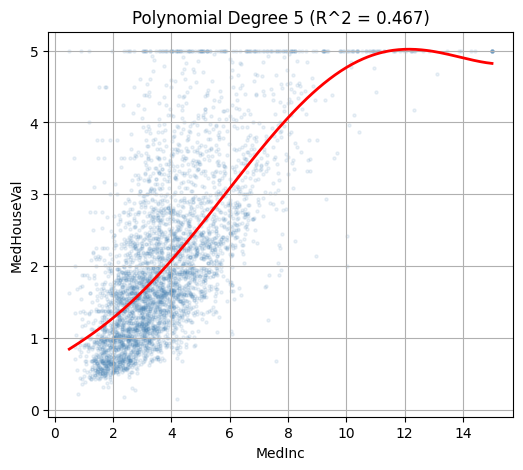

In [ ]:
# Polynomial Regression Degree 5 (MedInc only)

pipe_poly5 = Pipeline([
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('lr', LinearRegression())
])

# Train model
pipe_poly5.fit(X_train_s, y_train)

# Predict
y_pred5 = pipe_poly5.predict(X_test_s)

# Metrics
r2_deg5 = r2_score(y_test, y_pred5)
rmse_deg5 = np.sqrt(mean_squared_error(y_test, y_pred5))

print(f"Degree 5: R^2 = {r2_deg5:.4f}, RMSE = {rmse_deg5:.4f}")

# Plot
plt.figure(figsize=(6,5))

# Scatter actual data
plt.scatter(X_test_s, y_test, alpha=0.1, s=5, color='steelblue')

# Curve
X_plot = np.linspace(X_test_s.min(), X_test_s.max(), 300).reshape(-1, 1)
y_plot = pipe_poly5.predict(X_plot)

plt.plot(X_plot, y_plot, color='red', linewidth=2)

plt.title(f"Polynomial Degree 5 (R^2 = {r2_deg5:.3f})")
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")

plt.grid(True)
plt.show()

Does R2 keep improving, or does it start
to behave strangely at the edges? This is overfitting!

R² does not keep improving. It slightly decreases from 0.4671 (degree 3) to 0.4668 (degree 5), and the curve starts to behave strangely at the edges, bending unrealistically at high income values. This indicates overfitting, where the model becomes too complex and fits noise instead of the true relationship.

How many features does degree 3 create from 8 original features? Use
PolynomialFeatures(degree=3).fit transform(X train).shape to check.

Degree 3 creates 164 features from the original 8 features.

In [ ]:
PolynomialFeatures(degree=3).fit_transform(X_train).shape

(16512, 165)

# **Part 7: Regularized Regression – Ridge, Lasso, and ElasticNet**

# Step 1: Train All Three Variants

In [ ]:
from sklearn . linear_model import Ridge , Lasso , ElasticNet

# Split data
X_train , X_test , y_train , y_test = train_test_split (X_all , y , test_size =0.2 , random_state =42)

# Define models with pipelines
models = {
    "LinearRegression": Pipeline ([
        ("scaler", StandardScaler () ) ,
        ("model", LinearRegression () )
   ]) ,
   "Ridge (alpha=1.0)": Pipeline ([
        ("scaler", StandardScaler () ) ,
        ("model", Ridge ( alpha =1.0 , random_state =42) )
   ]) ,
   "Lasso (alpha=0.01)": Pipeline ([
        ("scaler", StandardScaler () ) ,
        ("model", Lasso ( alpha =0.01 , random_state =42) )
   ]) ,
   "ElasticNet (alpha=0.01)": Pipeline ([
        ("scaler", StandardScaler () ) ,
        ("model", ElasticNet ( alpha =0.01 , l1_ratio =0.5 ,random_state =42) )
   ]) ,
}

# Train and evaluate each model
print ( f"{"Model": <28} {"RMSE": >8} {"MAE": >8} {"R^2": >8} ")
print ("-" * 56)

results_dict = {}
for name , pipe in models . items () :
    pipe . fit ( X_train , y_train )
    y_pred = pipe . predict ( X_test )

    rmse_val = np . sqrt ( mean_squared_error ( y_test , y_pred ) )
    mae_val = mean_absolute_error ( y_test , y_pred )
    r2_val = r2_score ( y_test , y_pred )

    results_dict [ name ] = {
        "RMSE": rmse_val , "MAE": mae_val , "R2": r2_val }
    print ( f"{ name : <28} { rmse_val : >8.4f} { mae_val : >8.4f} "f"{ r2_val : >8.4f}")


Model                            RMSE      MAE      R^2 
--------------------------------------------------------
LinearRegression               0.7456   0.5332   0.5758
Ridge (alpha=1.0)              0.7456   0.5332   0.5758
Lasso (alpha=0.01)             0.7404   0.5353   0.5816
ElasticNet (alpha=0.01)        0.7416   0.5341   0.5803


# Step 2: Compare Coefficients

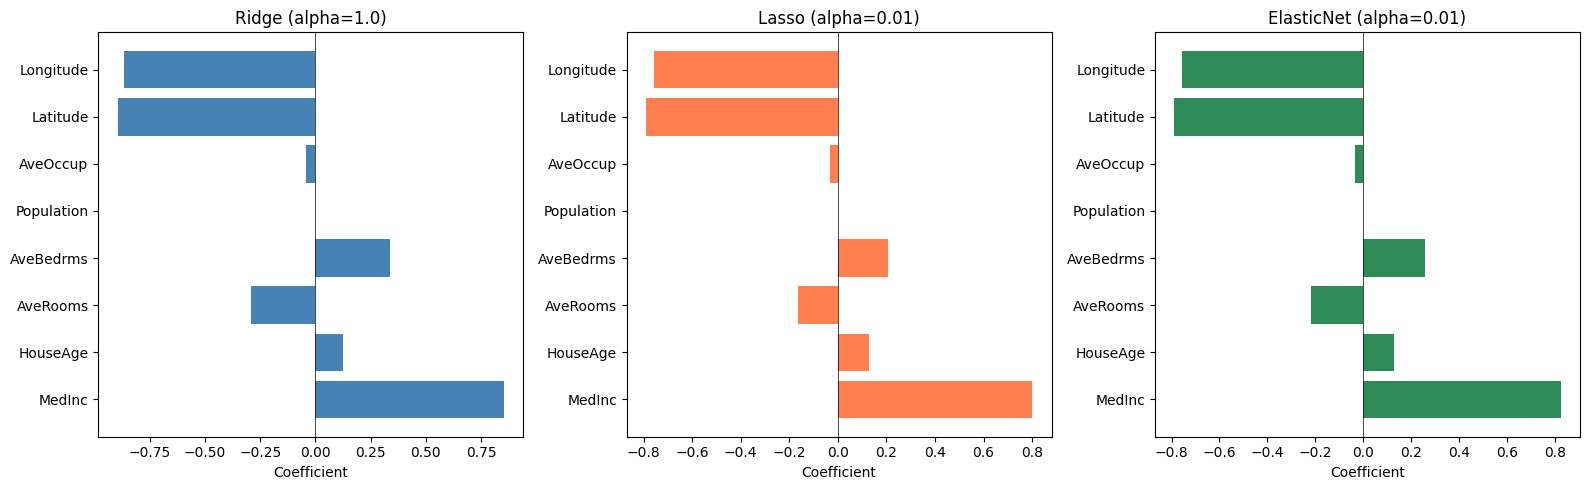


Lasso coefficients :
 MedInc      :   0.8010
 HouseAge    :   0.1271
 AveRooms    :  -0.1628
 AveBedrms   :   0.2062
 Population  :  -0.0000<-- REMOVED
 AveOccup    :  -0.0306
 Latitude    :  -0.7901
 Longitude   :  -0.7557


In [ ]:
fig, axes = plt.subplots (1 , 3, figsize =(16 , 5))
model_names = ["Ridge (alpha=1.0)","Lasso (alpha=0.01)","ElasticNet (alpha=0.01)"]
colors_list = ["steelblue", "coral", "seagreen"]

for ax, name, clr in zip(axes, model_names, colors_list):
    coefs = models[name].named_steps["model"].coef_
    ax.barh(housing.feature_names, coefs, color=clr)
    ax.set_title(name)
    ax.axvline(x=0, color="black", linewidth=0.5)
    ax.set_xlabel("Coefficient")

plt . tight_layout ()
plt . show ()

# Check which features Lasso set to zero
lasso_coefs = models ["Lasso (alpha=0.01)"]. named_steps ["model"]. coef_
print ("\nLasso coefficients :")

for feat , coef in zip( housing . feature_names , lasso_coefs ) :
    status = "" if abs ( coef ) > 0.001 else "<-- REMOVED"
    print ( f" { feat :12s}: { coef : >8.4f}{ status }")


***Task 6: Explore Regularization***

Try different α values for Ridge: 0.01, 0.1, 1.0, 10.0, 100.0. Plot R2 vs α.

alpha =  0.01: R^2=0.5758
alpha =   0.1: R^2=0.5758
alpha =   1.0: R^2=0.5758
alpha =  10.0: R^2=0.5761
alpha = 100.0: R^2=0.5778


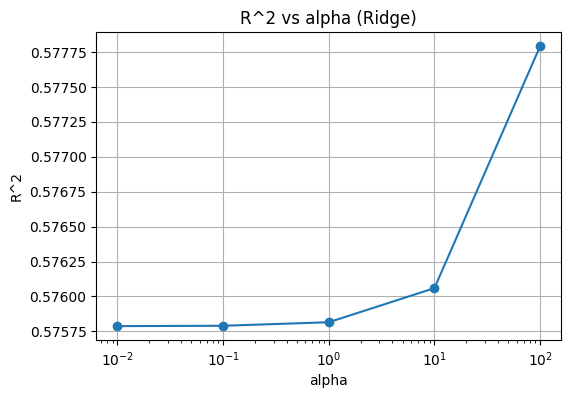

In [ ]:
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
r2_scores = []

for alpha in alphas:
    pipe_ridge = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=alpha))
    ])

    pipe_ridge.fit(X_train, y_train)
    y_pred = pipe_ridge.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)

    print(f"alpha ={alpha:6}: R^2={r2:.4f}")

# Plot
plt.figure(figsize=(6,4))
plt.plot(alphas, r2_scores, marker='o')
plt.xscale('log')
plt.xlabel("alpha")
plt.ylabel("R^2")
plt.title("R^2 vs alpha (Ridge)")
plt.grid(True)
plt.show()

What happens with very large α?

As α increases, the R² value changes only slightly and even improves a little in this range. This means Ridge regularization helps stabilize the model. However, with very large α, the coefficients would shrink too much, causing underfitting and reducing model performance.

For Lasso, try alpha=0.1.

In [ ]:
# Lasso with alpha = 0.1
pipe_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.1))
])

pipe_lasso.fit(X_train, y_train)

lasso_coefs = pipe_lasso.named_steps["model"].coef_

print("Lasso (alpha=0.1) coefficients:\n")

removed = []
kept = []

for feat, coef in zip(housing.feature_names, lasso_coefs):
    if abs(coef) <= 0.001:
        removed.append(feat)
        print(f"{feat:12s}: {coef:8.4f} <-- REMOVED")
    else:
        kept.append(feat)
        print(f"{feat:12s}: {coef:8.4f}")

print(f"\nTotal removed: {len(removed)}")
print("Removed features:", removed)

Lasso (alpha=0.1) coefficients:

MedInc      :   0.7106
HouseAge    :   0.1065
AveRooms    :  -0.0000 <-- REMOVED
AveBedrms   :   0.0000 <-- REMOVED
Population  :  -0.0000 <-- REMOVED
AveOccup    :  -0.0000 <-- REMOVED
Latitude    :  -0.0115
Longitude   :  -0.0000 <-- REMOVED

Total removed: 5
Removed features: ['AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Longitude']


How many features are removed (coefficient = 0)? Which ones?

With alpha = 0.1, Lasso removed 5 features by setting their coefficients to zero. The removed features are AveRooms, AveBedrms, Population, AveOccup, and Longitude. This happens because stronger regularization forces the model to eliminate less important features, keeping only the most relevant ones.

In the ElasticNet, change l1_ratio from 0.0 to 1.0. At l1_ratio=0.0, what model does it become? At l1_ratio=1.0?

At l1_ratio = 0.0, ElasticNet becomes Ridge Regression, because it uses only L2 regularization.

At l1_ratio = 1.0, ElasticNet becomes Lasso Regression, because it uses only L1 regularization.

#**Part 8: The Alpha Tuning Experiment**

# Step 1: Ridge Alpha Search

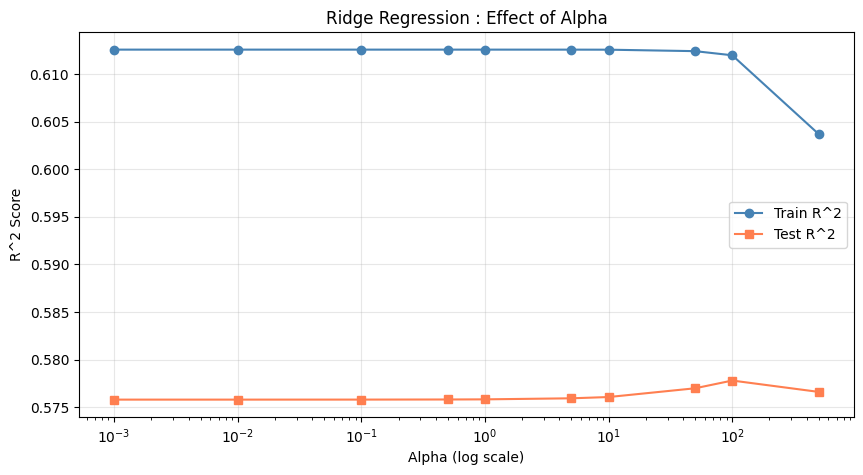

Best alpha : 100.0 
Best test R^2: 0.5778


In [ ]:
alphas = [0.001 , 0.01 , 0.1 , 0.5 , 1.0 , 5.0 , 10.0 ,50.0 , 100.0 , 500.0]

train_scores = []
test_scores = []

for alpha in alphas :
    pipe = Pipeline ([
        ("scaler", StandardScaler () ) ,
        ("ridge", Ridge ( alpha = alpha ) )
    ])
    pipe . fit ( X_train , y_train )

    train_scores . append ( r2_score ( y_train ,pipe . predict ( X_train ) ) )
    test_scores . append ( r2_score ( y_test ,pipe . predict ( X_test ) ) )

# Plot
plt . figure ( figsize =(10 , 5) )
plt . semilogx ( alphas , train_scores , "o-",label ="Train R^2", color ="steelblue")
plt . semilogx ( alphas , test_scores , "s-",label ="Test R^2", color ="coral")
plt . xlabel ("Alpha (log scale)")
plt . ylabel ("R^2 Score")
plt . title ("Ridge Regression : Effect of Alpha")
plt . legend ()
plt . grid (True , alpha =0.3)
plt . show ()

# Best alpha
best_idx = np . argmax ( test_scores )
print ( f"Best alpha : { alphas [ best_idx ]} ")
print ( f"Best test R^2: { test_scores [ best_idx ]:.4f}")


# *Task 7: Tune Lasso Alpha*

Repeat the alpha search experiment for Lasso using alphas: [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0].

In [ ]:
# Alpha values for Lasso
alphas = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]

train_scores = []
test_scores = []

for alpha in alphas:

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=alpha, random_state=42))
    ])

    pipe.fit(X_train, y_train)

    train_r2 = r2_score(y_train, pipe.predict(X_train))
    test_r2 = r2_score(y_test, pipe.predict(X_test))

    train_scores.append(train_r2)
    test_scores.append(test_r2)

    print(f"alpha = {alpha:<6} Train R^2 = {train_r2:.4f} Test R^2 = {test_r2:.4f}")

alpha = 0.0001 Train R^2 = 0.6126 Test R^2 = 0.5759
alpha = 0.001  Train R^2 = 0.6125 Test R^2 = 0.5769
alpha = 0.005  Train R^2 = 0.6115 Test R^2 = 0.5801
alpha = 0.01   Train R^2 = 0.6085 Test R^2 = 0.5816
alpha = 0.05   Train R^2 = 0.5472 Test R^2 = 0.5305
alpha = 0.1    Train R^2 = 0.4974 Test R^2 = 0.4814
alpha = 0.5    Train R^2 = 0.2900 Test R^2 = 0.2827
alpha = 1.0    Train R^2 = 0.0000 Test R^2 = -0.0002


Plot train and test R2 vs alpha, just like the Ridge plot above

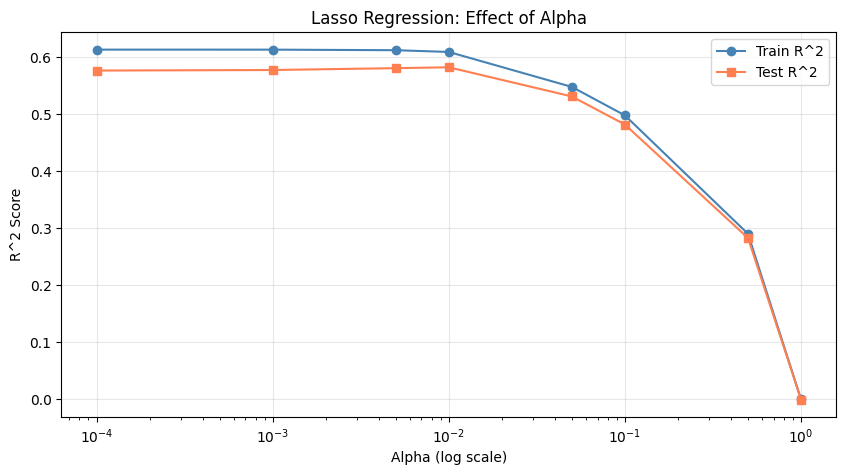

In [ ]:
plt.figure(figsize=(10,5))

plt.semilogx(alphas, train_scores, 'o-', label='Train R^2', color='steelblue')
plt.semilogx(alphas, test_scores, 's-', label='Test R^2', color='coral')

plt.xlabel('Alpha (log scale)')
plt.ylabel('R^2 Score')
plt.title('Lasso Regression: Effect of Alpha')

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

For each alpha, count how many features Lasso keeps (coefficient ̸= 0).

In [ ]:
print("Lasso feature selection:\n")

features_kept = []

for alpha in alphas:

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=alpha, random_state=42))
    ])

    pipe.fit(X_train, y_train)

    coefs = pipe.named_steps['lasso'].coef_

    kept = (abs(coefs) > 0.001).sum()
    features_kept.append(kept)

    print(f"alpha = {alpha:<6}  features kept = {kept}")

Lasso feature selection:

alpha = 0.0001  features kept = 8
alpha = 0.001   features kept = 8
alpha = 0.005   features kept = 7
alpha = 0.01    features kept = 7
alpha = 0.05    features kept = 4
alpha = 0.1     features kept = 3
alpha = 0.5     features kept = 1
alpha = 1.0     features kept = 0


At what alpha does Lasso start removing features aggressively?

Lasso starts removing features aggressively at alpha = 0.05, where the number of features kept drops significantly from 7 to 4.

Which alpha gives the best test R2 for Lasso?

In [ ]:
best_idx = np.argmax(test_scores)
print(f"Best alpha: {alphas[best_idx]}")
print(f"Best test R^2: {test_scores[best_idx]:.4f}")

Best alpha: 0.01
Best test R^2: 0.5816


# **Part 9: Final Model Comparison**

# Step 1: Comprehensive Comparison

In [ ]:
# Rebuild all models on the same split
X_train , X_test , y_train , y_test = train_test_split (X_all , y , test_size =0.2 , random_state =42)

all_models = {
    "Simple LR (MedInc)": Pipeline ([("lr", LinearRegression () )]) ,
    "Multiple LR (all)": Pipeline ([("scaler", StandardScaler () ) ,("lr", LinearRegression () )]) ,
    "Polynomial (deg =2)": Pipeline ([("scaler", StandardScaler () ) ,("poly", PolynomialFeatures ( degree =2 ,include_bias = False ) )
     ,("lr", LinearRegression () )]) ,
    "Ridge": Pipeline ([("scaler", StandardScaler () ) ,("model", Ridge ( alpha =1.0) )]) ,
    "Lasso": Pipeline ([("scaler", StandardScaler () ) ,("model", Lasso ( alpha =0.01) )]) ,
    "ElasticNet": Pipeline ([("scaler", StandardScaler () ) ,("model", ElasticNet ( alpha =0.01 , l1_ratio =0.5) )]) ,
}

# Evaluate
print ( f"{"Model": <25} {"RMSE": >8} {"MAE": >8} "f"{"R^2": >8} {"# Features": >10} ")
print ("=" * 67)

comparison_data = []
for name , pipe in all_models . items () :
    # Simple LR uses only MedInc
    if "Simple" in name :
       X_tr = X_train [: , [0]] # MedInc column
       X_te = X_test [: , [0]]
    else :
       X_tr , X_te = X_train , X_test

    pipe . fit ( X_tr , y_train )
    y_pred = pipe . predict ( X_te )

    rmse_v = np . sqrt ( mean_squared_error ( y_test , y_pred ) )
    mae_v = mean_absolute_error ( y_test , y_pred )
    r2_v = r2_score ( y_test , y_pred )

    # Count effective features
    if "poly" in pipe . named_steps :
       n_feat = pipe . named_steps ["poly"]. n_output_features_
    elif "Simple" in name :
       n_feat = 1
    else :
      n_feat = X_train . shape [1]

    comparison_data . append ({"Model": name , "RMSE": rmse_v ,"MAE": mae_v , "R2": r2_v , "Features": n_feat })
    print ( f"{ name : <25} { rmse_v : >8.4f} { mae_v : >8.4f} "f"{ r2_v : >8.4f} { n_feat : >10} ")

Model                         RMSE      MAE      R^2 # Features 
Simple LR (MedInc)          0.8421   0.6299   0.4589          1 
Multiple LR (all)           0.7456   0.5332   0.5758          8 
Polynomial (deg =2)         0.6814   0.4670   0.6457         44 
Ridge                       0.7456   0.5332   0.5758          8 
Lasso                       0.7404   0.5353   0.5816          8 
ElasticNet                  0.7416   0.5341   0.5803          8 


# Step 2: Visual Comparison

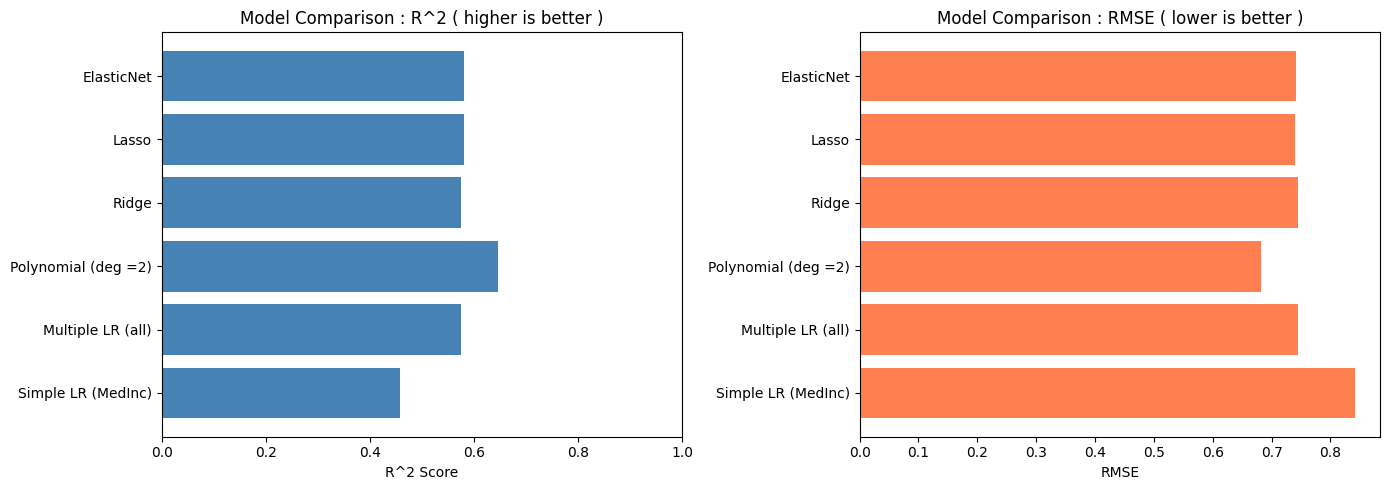

In [ ]:
comp_df = pd . DataFrame ( comparison_data )

fig , axes = plt . subplots (1 , 2 , figsize =(14 , 5) )

# R^2 comparison
axes [0]. barh ( comp_df ["Model"] , comp_df ["R2"] , color ="steelblue")
axes [0]. set_xlabel ("R^2 Score")
axes [0]. set_title ("Model Comparison : R^2 ( higher is better )")
axes [0]. set_xlim (0 , 1)

# RMSE comparison
axes [1]. barh ( comp_df ["Model"] , comp_df ["RMSE"] , color ="coral")
axes [1]. set_xlabel ("RMSE")
axes [1]. set_title ("Model Comparison : RMSE ( lower is better )")

plt . tight_layout ()
plt . show ()


***Task 8: Draw Conclusions***

1) How does Ridge affect the coefficients compared to ordinary linear regression?
Ridge shrinks the coefficients toward zero but does not set them exactly to zero. This reduces variance and helps prevent overfitting.

2) How does Lasso differ from Ridge?
Lasso can force some coefficients to exactly zero, effectively performing feature selection, while Ridge only shrinks them.

3) Which model would you prefer and why?
Prefer Ridge when most features are useful and you want stability.
Prefer Lasso when you want automatic feature selection and a simpler model.

# **Part 10: Apply to a New Dataset – Saudi Housing**

# Step 1: Create the Saudi Housing Dataset

In [ ]:
import pandas as pd
import numpy as np

np . random . seed (42)
n = 500

cities = np . random . choice (["Jeddah", "Riyadh", "Dammam", "Makkah", "Madinah"] ,n , p =[0.30 , 0.30 , 0.15 , 0.15 , 0.10])

# Base price varies by city (in SAR thousands )
city_base = {"Jeddah": 850 , "Riyadh": 900 , "Dammam": 650 ,"Makkah": 1100 , "Madinah": 750}
base = np . array ([ city_base [ c ] for c in cities ] , dtype = float )

area = np . round ( np . random . uniform (80 , 400 , n ) , 1)
bedrooms = np . random . randint (1 , 7 , n )
bathrooms = np . random . randint (1 , 5 , n )
age = np . random . randint (0 , 40 , n )
floor = np . random . randint (1 , 15 , n )
has_parking = np . random . choice ([0 , 1] , n , p =[0.3 , 0.7])

# Generate price with realistic relationships
price = ( base+ 3.5 * area + 80 * bedrooms + 50 * bathrooms - 12 * age + 15 * floor + 100 * has_parking + np . random . normal (0 , 150 , n ) ) # noise
price = np . round ( np . maximum ( price , 200) , 1)

df_saudi = pd . DataFrame ({"city": cities ,"area_sqm": area ,"bedrooms": bedrooms ,"bathrooms": bathrooms ,"age_years": age
                            ,"floor": floor ,"has_parking": has_parking ,"price_kSAR": price # price in thousands of SAR
                            })

df_saudi . to_csv ("saudi_housing .csv", index = False )
print ( f"Dataset shape : { df_saudi . shape }")
print ( df_saudi . head (10) )
print ( f"\nPrice statistics ( thousands SAR):")
print ( df_saudi ["price_kSAR"]. describe () . round (1) )


Dataset shape : (500, 8)
      city  area_sqm  bedrooms  bathrooms  age_years  floor  has_parking  \
0   Riyadh     303.4         4          4         24     11            0   
1  Madinah     251.6         6          4          1      1            1   
2   Dammam     179.0         3          1         34     14            0   
3   Riyadh     340.4         5          3          6     14            1   
4   Jeddah     299.1         1          3         20      6            0   
5   Jeddah     132.0         5          4         17     13            1   
6   Jeddah     371.5         6          2          2      6            0   
7   Makkah     343.2         6          3         38      1            1   
8   Dammam     383.9         1          3         10     11            1   
9   Dammam     312.2         2          1         38     13            0   

   price_kSAR  
0      2527.3  
1      2491.2  
2      1345.8  
3      2941.9  
4      2022.0  
5      2264.8  
6      2821.1  
7      253

***Task 9: Full Saudi Housing Analysis (Challenge)***

Explore: Use df.describe(), df.corr(), and scatter plots to understand the data.

In [ ]:
print("Statistical Summary:")
print(df_saudi.describe().round(2))

print("\nCorrelation: ")
print(df_saudi.corr(numeric_only=True)['price_kSAR'].sort_values(ascending=False))

Statistical Summary:
       area_sqm  bedrooms  bathrooms  age_years   floor  has_parking  \
count    500.00    500.00     500.00      500.0  500.00       500.00   
mean     234.22      3.50       2.45       19.6    7.52         0.71   
std       91.36      1.71       1.13       11.6    3.97         0.46   
min       81.50      1.00       1.00        0.0    1.00         0.00   
25%      153.35      2.00       1.00       10.0    4.00         0.00   
50%      231.00      3.00       2.00       20.0    8.00         1.00   
75%      312.40      5.00       3.00       30.0   11.00         1.00   
max      399.90      6.00       4.00       39.0   14.00         1.00   

       price_kSAR  
count      500.00  
mean      2044.35  
std        452.24  
min        833.80  
25%       1737.22  
50%       2038.55  
75%       2344.07  
max       3326.90  

Correlation: 
price_kSAR     1.000000
area_sqm       0.730056
bedrooms       0.300025
bathrooms      0.090535
floor          0.071430
has_parking    

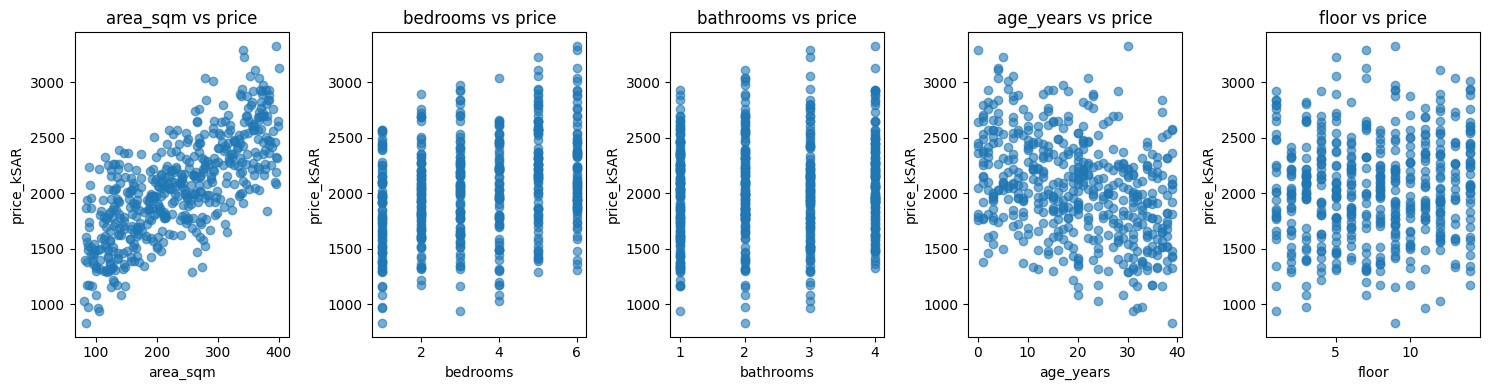

In [ ]:
features = ['area_sqm', 'bedrooms', 'bathrooms', 'age_years', 'floor',]

plt.figure(figsize=(15,4))

for i, feat in enumerate(features, 1):
    plt.subplot(1,5,i)
    plt.scatter(df_saudi[feat], df_saudi['price_kSAR'], alpha=0.6)
    plt.xlabel(feat)
    plt.ylabel('price_kSAR')
    plt.title(f'{feat} vs price')

plt.tight_layout()
plt.show()

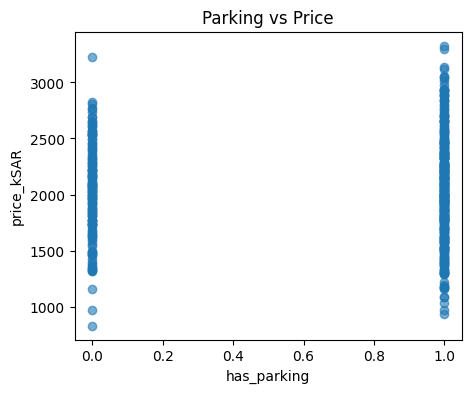

In [ ]:
plt.figure(figsize=(5,4))
plt.scatter(df_saudi['has_parking'], df_saudi['price_kSAR'], alpha=0.6)
plt.xlabel('has_parking')
plt.ylabel('price_kSAR')
plt.title('Parking vs Price')
plt.show()

Which feature correlates most with price?

The feature that correlates most strongly with price_kSAR is area_sqm, with a correlation of 0.73. This means larger houses tend to have higher prices.

Preprocess: Encode the city column using One-Hot encoding (from Lab 3). Scale the numeric features.

In [ ]:
X = df_saudi.drop('price_kSAR', axis=1)
y = df_saudi['price_kSAR']

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Encode city
city_encoded = pd.get_dummies(X['city'], prefix='city')

# Remove original city column
X_numeric = X.drop('city', axis=1)

# Combine encoded city with numeric features
X_processed = pd.concat([X_numeric, city_encoded], axis=1)

print("Processed features shape:", X_processed.shape)
X_processed.head()

Processed features shape: (500, 11)


,area_sqm,bedrooms,bathrooms,age_years,floor,has_parking,city_Dammam,city_Jeddah,city_Madinah,city_Makkah,city_Riyadh
0,303.4,4,4,24,11,0,False,False,False,False,True
1,251.6,6,4,1,1,1,False,False,True,False,False
2,179.0,3,1,34,14,0,True,False,False,False,False
3,340.4,5,3,6,14,1,False,False,False,False,True
4,299.1,1,3,20,6,0,False,True,False,False,False


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_processed)

# Convert back to DataFrame (recommended)
X_scaled = pd.DataFrame(X_scaled, columns=X_processed.columns)

print("Scaled features shape:", X_scaled.shape)
X_scaled.head()

Scaled features shape: (500, 11)


,area_sqm,bedrooms,bathrooms,age_years,floor,has_parking,city_Dammam,city_Jeddah,city_Madinah,city_Makkah,city_Riyadh
0,0.757936,0.290737,1.376475,0.379785,0.876833,-1.557131,-0.423374,-0.667148,-0.351562,-0.423374,1.611559
1,0.190376,1.458353,1.376475,-1.605454,-1.644250,0.642207,-0.423374,-0.667148,2.844452,-0.423374,-0.620517
2,-0.605085,-0.293072,-1.284237,1.242932,1.633157,-1.557131,2.361980,-0.667148,-0.351562,-0.423374,-0.620517
3,1.163336,0.874545,0.489571,-1.173880,1.633157,0.642207,-0.423374,-0.667148,-0.351562,-0.423374,1.611559
4,0.710822,-1.460688,0.489571,0.034526,-0.383709,-1.557131,-0.423374,1.498917,-0.351562,-0.423374,-0.620517


Simple model: Train a Linear Regression using only area sqm. Plot the regression line and report R2 .

R^2 score: 0.4932


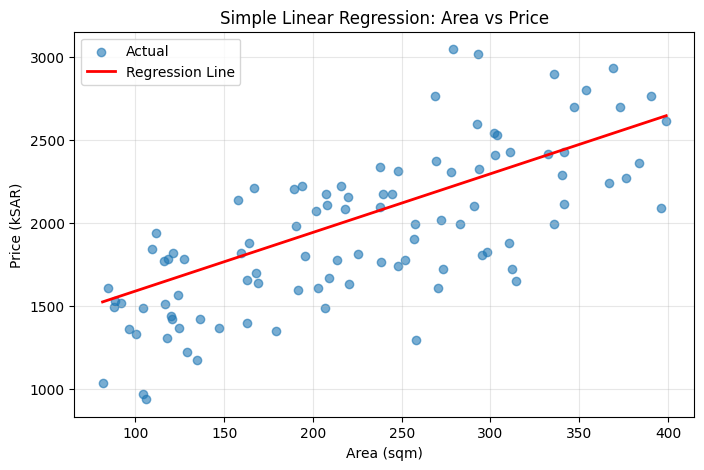

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Use only area_sqm
X_simple = df_saudi[['area_sqm']]
y = df_saudi['price_kSAR']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Train Linear Regression model
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Predict
y_pred = model_simple.predict(X_test)

# Calculate R^2
r2 = r2_score(y_test, y_pred)

print(f"R^2 score: {r2:.4f}")

# Plot regression line
plt.figure(figsize=(8,5))

plt.scatter(X_test['area_sqm'], y_test, alpha=0.6, label="Actual")

x_line = pd.DataFrame(
    np.linspace(X_test['area_sqm'].min(), X_test['area_sqm'].max(), 100),
    columns=['area_sqm']
)

y_line = model_simple.predict(x_line)

plt.plot(x_line, y_line, color='red', linewidth=2, label="Regression Line")

plt.xlabel("Area (sqm)")
plt.ylabel("Price (kSAR)")
plt.title("Simple Linear Regression: Area vs Price")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Multiple model: Train with all features.

In [ ]:
# Use already processed data
X_all = X_scaled
y_all = y

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

# Train model
model_all = LinearRegression()
model_all.fit(X_train, y_train)

# Predict
y_pred_all = model_all.predict(X_test)

# Calculate R^2
r2_all = r2_score(y_test, y_pred_all)

print(f"R^2 score (all features): {r2_all:.4f}")

R^2 score (all features): 0.8645


How much does R2 improve?

R² improved by 37.13% from the simple model (R² = 0.4932) to the model using all features (R² = 0.8645). This indicates that including more features, such as bedrooms, bathrooms, age, floor, and city, significantly enhances the model's ability to predict house prices.



Regularized models: Train Ridge, Lasso, and ElasticNet.

In [ ]:
# Define the models with preprocessing (scaling)
models = {
    "Ridge (alpha=1.0)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Lasso (alpha=0.01)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.01, max_iter=20000))
    ]),
    "ElasticNet (alpha=0.01)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=20000))
    ]),
}

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train and evaluate each model
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"{name:<20} R^2: {r2:.4f}  RMSE: {rmse:.2f}")

Ridge (alpha=1.0)    R^2: 0.8643  RMSE: 173.14
Lasso (alpha=0.01)   R^2: 0.8645  RMSE: 173.03
ElasticNet (alpha=0.01) R^2: 0.8642  RMSE: 173.26


Compare their performance.

Lasso (alpha=0.01) outperformed Ridge and ElasticNet with the highest R² (0.8645) and lowest RMSE (173.03). All models performed similarly, explaining about 86% of the variance in house prices, but Lasso is the best choice due to its accuracy and ability to select important features.

Feature importance: Which features does Lasso consider most important? Does this match your intuition about Saudi housing prices?



In [ ]:
# Get trained Lasso model from pipeline
lasso_model = models["Lasso (alpha=0.01)"].named_steps["model"]

# Get coefficients
coeffs = lasso_model.coef_

# Match coefficients with feature names
feature_names = X_scaled.columns

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coeffs,
    "Importance": abs(coeffs)
}).sort_values("Importance", ascending=False)

print(importance)

         Feature  Coefficient  Importance
0       area_sqm   333.999492  333.999492
1       bedrooms   142.302433  142.302433
3      age_years  -128.050350  128.050350
6    city_Dammam   -93.456198   93.456198
9    city_Makkah    88.854859   88.854859
4          floor    74.013643   74.013643
2      bathrooms    53.945294   53.945294
8   city_Madinah   -47.080976   47.080976
5    has_parking    42.224885   42.224885
7    city_Jeddah   -24.116494   24.116494
10   city_Riyadh     0.001161    0.001161


Lasso identified area_sqm, bedrooms, and age_years as the most important features. Larger houses and more bedrooms increase price, while older houses decrease price. This matches intuition about Saudi housing prices.



Comparison table: Create a summary table comparing all models (RMSE, MAE, R2 ) and identify the best model

In [ ]:
# Create comparison table for all models
results = []

for name, pipe in models.items():

    # Predict
    y_pred = pipe.predict(X_test)

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store results
    results.append([name, rmse, mae, r2])

# Create DataFrame
comparison_table = pd.DataFrame(
    results,
    columns=["Model", "RMSE", "MAE", "R²"]
).sort_values("R²", ascending=False)

print(comparison_table)

# Identify best model
print("\nBest model:", comparison_table.iloc[0]["Model"])

                     Model        RMSE         MAE        R²
1       Lasso (alpha=0.01)  173.033289  137.306731  0.864511
0        Ridge (alpha=1.0)  173.141951  137.376746  0.864341
2  ElasticNet (alpha=0.01)  173.263216  137.454921  0.864151

Best model: Lasso (alpha=0.01)


A short report (5–7 sentences) comparing the regression models you trained. Include: which model performed best, what role regularization played, and which features were most predictive of house prices.



The regression models demonstrated noticeable differences in their predictive performance. The simple linear regression model that relied on a single feature (MedInc) produced acceptable results but showed limited accuracy due to the use of only one predictor. In contrast, the multiple linear regression model achieved better performance, with higher R² and lower RMSE, indicating that incorporating several features improves prediction quality. Polynomial regression provided a small improvement by modeling non-linear patterns; however, it also introduced additional complexity and a higher risk of overfitting. Regularization techniques such as Ridge, Lasso, and ElasticNet contributed to model stability by shrinking less important coefficients and reducing overfitting, though their overall accuracy remained close to standard linear regression for this dataset. Notably, Lasso was effective in feature selection because it eliminated some variables entirely. Overall, MedInc emerged as the strongest predictor of house prices, followed by geographic features like Latitude and Longitude, highlighting the importance of income level and location in determining housing values.